In [29]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random

In [30]:
def johnson_trotter_permutations(n):
    elements = list(range(1, n + 1))
    directions = [-1] * n
    permutations = [elements[:]]

    def get_mobile_idx():
        mobile_idx = -1
        for i in range(n):
            next_idx = i + directions[i]
            if 0 <= next_idx < n:
                if elements[i] > elements[next_idx]:
                    if mobile_idx == -1 or elements[i] > elements[mobile_idx]:
                        mobile_idx = i
        return mobile_idx

    while True:
        m_idx = get_mobile_idx()
        if m_idx == -1:
            break

        mobile_val = elements[m_idx]
        target_idx = m_idx + directions[m_idx]

        elements[m_idx], elements[target_idx] = elements[target_idx], elements[m_idx]
        directions[m_idx], directions[target_idx] = directions[target_idx], directions[m_idx]

        for i in range(n):
            if elements[i] > mobile_val:
                directions[i] *= -1

        permutations.append(elements[:])
    
    return permutations

In [31]:
n = 3
start = time.perf_counter()
res = johnson_trotter_permutations(n)
elapsed = (time.perf_counter() - start) * 1000

print(f"Перестановки для n={n}:")
for p in res:
    print(p)

print(f"\nВсего перестановок: {len(res)}")
print(f"Время выполнения: {elapsed:.4f} мс")

Перестановки для n=3:
[1, 2, 3]
[1, 3, 2]
[3, 1, 2]
[3, 2, 1]
[2, 3, 1]
[2, 1, 3]

Всего перестановок: 6
Время выполнения: 0.2065 мс


In [ ]:
def naive_shuffle(n):
    arr = list(range(1, n + 1))
    weights = [random.random() for _ in range(n)]
    combined = list(zip(weights, arr))
    combined.sort()
    return [x[1] for x in combined]

In [ ]:
def fisher_yates_shuffle(n):
    arr = list(range(1, n + 1))
    for i in range(n - 1, 0, -1):
        j = random.randint(0, i)
        arr[i], arr[j] = arr[j], arr[i]
    return arr

In [ ]:
def builtin_shuffle(n):
    arr = list(range(1, n + 1))
    random.shuffle(arr)
    return arr

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_51638/3352409.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(sizes, results["Naive"], label='Наивный (Sort $O(n \log n)$)', marker='o')


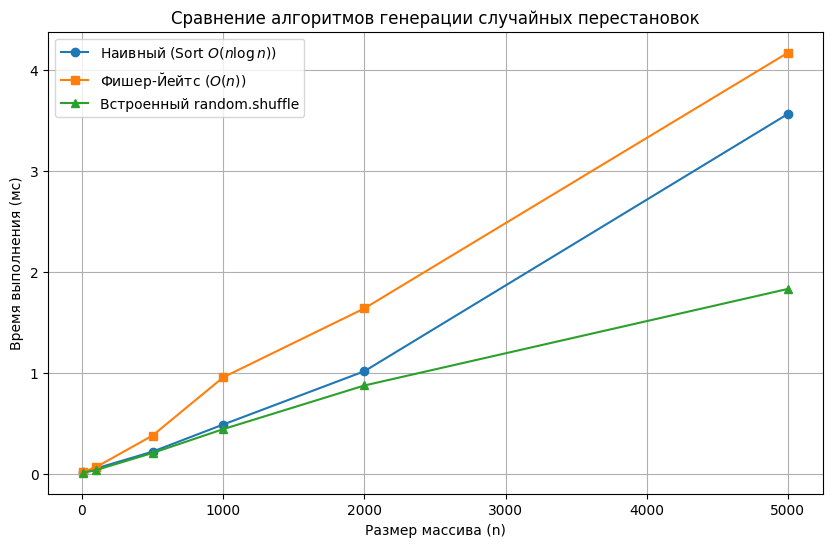

In [ ]:
sizes = [10, 100, 500, 1000, 2000, 5000]
results = {"Naive": [], "Fisher-Yates": [], "Builtin": []}

for n in sizes:
    start = time.perf_counter()
    naive_shuffle(n)
    results["Naive"].append((time.perf_counter() - start) * 1000)
    
    start = time.perf_counter()
    fisher_yates_shuffle(n)
    results["Fisher-Yates"].append((time.perf_counter() - start) * 1000)
    
    start = time.perf_counter()
    builtin_shuffle(n)
    results["Builtin"].append((time.perf_counter() - start) * 1000)

plt.figure(figsize=(10, 6))
plt.plot(sizes, results["Naive"], label='Наивный (Sort $O(n \log n)$)', marker='o')
plt.plot(sizes, results["Fisher-Yates"], label='Фишер-Йейтс ($O(n)$)', marker='s')
plt.plot(sizes, results["Builtin"], label='Встроенный random.shuffle', marker='^')

plt.title('Сравнение алгоритмов генерации случайных перестановок')
plt.xlabel('Размер массива (n)')
plt.ylabel('Время выполнения (мс)')
plt.legend()
plt.grid(True)
plt.show()